# Support Vector Machines: exercises

This notebook is a structured exercise sheet to accompany the SVM demo.

The problems move from geometry to convex optimization, then to PCA and kernels.
For each exercise, first work it out on paper, then use the code cells to test your result.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC, LinearSVC
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(7)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

def plot_points(X, y, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots()
    for label, marker in [(-1, 'o'), (1, '^')]:
        ax.scatter(X[y == label, 0], X[y == label, 1], marker=marker, label=f'class {label}')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    if title:
        ax.set_title(title)
    ax.legend()
    return ax


def _mesh_from_data(X, padding=1.0, n=400):
    x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n), np.linspace(y_min, y_max, n))
    return xx, yy


def plot_decision_function(clf, X, y, ax=None, title=None, show_support=True):
    if ax is None:
        fig, ax = plt.subplots()
    plot_points(X, y, ax=ax)
    xx, yy = _mesh_from_data(X)
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.decision_function(grid).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    if show_support and hasattr(clf, 'support_vectors_'):
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=180,
                   facecolors='none', edgecolors='k', linewidths=1.5, label='support vectors')
        ax.legend()
    if title:
        ax.set_title(title)
    return ax


def signed_distance(x, w, b):
    return (x @ w + b) / np.linalg.norm(w)


def fit_linear_svm(X, y, C=1e6):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X, y)
    return clf


## Exercise 1. Distance to a hyperplane


Let the hyperplane be $H = \{x : w^\top x + b = 0\}$ with $w \neq 0$.

1. Show that the signed distance from a point $x_0$ to $H$ is

$$
\frac{w^\top x_0 + b}{\|w\|}.
$$

2. Deduce that the Euclidean distance is

$$
\frac{|w^\top x_0 + b|}{\|w\|}.
$$

Write your proof below, then verify numerically with a concrete example.

Chcemy znaleźć odległość punktu od płaszczyzny, będzie ona prostopadła do płaszczyzny.
$$
\hat n = \frac{w}{\|w\|}.
$$
Wektor $\hat n$ ma długość 1 i prostopadły do hiperpłaszczyzny. Weźmy dowolny punkt $x_H$ spełniający równanie $w^\top x_H + b = 0$.
Odległość $d(x_0, x_H)$ nie będzie prostopadła, będziemy szukać składowych wektora - $v=x_0 - x_H$. Bierzemy rzut wektora $v$ na kierunek normalny $\hat n$.

$$
\operatorname{dist}_{\pm}(x_0, H)=\hat n^\top(x_0 - x_H) = \frac{w^\top}{\|w\|}(x_0 - x_H) =\frac{w^\top x_0-w^\top x_H}{\|w\|}
$$
Wiemy, że punkt $x_H$ leży na płaszczyźnie $H$, stąd otrzymujemy: 

$$
\operatorname{dist}_{\pm}(x_0, H)=\frac{w^\top x_0 + b}{\|w\|}.
$$

Odległość euklidesowa wynosi:
$$
\operatorname{dist}(x_0, H)=\frac{|w^\top x_0 + b|}{\|w\|}.
$$

In [5]:
# Write a small numerical check here.
w = np.array([3.0, -4.0])
b = 2.0
x0 = np.array([1.0, 2.0])

# TODO: compute the signed distance
# długość wektora w
w_norm = np.linalg.norm(w)

# signed distance
signed_dist = (np.dot(w, x0) + b) / w_norm

# Euclidean distance
euclid_dist = abs(signed_dist)

print("w =", w)
print("b =", b)
print("x0 =", x0)
print(f"Signed distance = {signed_dist:.4f}")
print(f"Euclidean distance = {euclid_dist:.4f}")

w = [ 3. -4.]
b = 2.0
x0 = [1. 2.]
Signed distance = -0.6000
Euclidean distance = 0.6000


## Exercise 2. Margin width


Assume the classifier is normalized so that

$$
y_i(w^\top x_i+b) \ge 1.
$$

Show that the two margin hyperplanes are $w^\top x+b=1$ and $w^\top x+b=-1$, and prove that the distance between them is

$$
\frac{2}{\|w\|}.
$$

Then fit a nearly hard-margin linear SVM to a separable 2D dataset and verify the formula numerically.


In [3]:
X = np.array([
    [-2.5, -0.8], [-2.0, 0.6], [-1.2, -1.3], [-0.9, 1.1],
    [ 1.1, -0.7], [ 1.5, 1.4], [ 2.0, -1.0], [ 2.6, 0.9],
])
y = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

# TODO: fit a linear SVM with large C and compute 2 / ||w||

fs = SVC(kernel='linear', C=1e6)
fs.fit(X, y)

w = fs.coef_[0]
margin_width = 2 / np.linalg.norm(w)
margin_width

np.float64(2.2084777952532115)

## Exercise 3. Convexity of hard-margin SVM


Consider the optimization problem

$$
\min_{w,b} \frac12\|w\|^2
\quad\text{subject to}\quad
y_i(w^\top x_i+b) \ge 1.
$$

Explain carefully why this is a convex optimization problem.

Your answer should explicitly identify:

- the objective function,
- the feasible set,
- why local minima are global minima in this setting.


This is a convex optimization problem because the objective function

$$
\frac12\|w\|^2
$$

is convex in $w$. In a convex optimization problem, every local minimum is also a global minimum, so the hard-margin SVM has no bad local minima.


In [ ]:
# Write a short paragraph in markdown above.


## Exercise 4. Dual representation of $w$


Starting from the Lagrangian

$$
L(w,b,\alpha) = \frac12\|w\|^2 - \sum_i \alpha_i\bigl(y_i(w^\top x_i+b)-1\bigr),
\qquad \alpha_i \ge 0,
$$

show that stationarity implies

$$
w = \sum_i \alpha_i y_i x_i,
\qquad
\sum_i \alpha_i y_i = 0.
$$

Then, using a fitted linear SVM, reconstruct $w$ from the support vectors and compare it with the model coefficient.

By taking derivatives of the Lagrangian and setting them to zero, we get

$$
w = \sum_i \alpha_i y_i x_i
$$

and

$$
\sum_i \alpha_i y_i = 0.
$$

This means that the separating vector $w$ is built from the training points. Points with non-zero $\alpha_i$ are the most important ones, because they directly define the decision boundary. These points are called support vectors.


In [5]:
X = np.array([
    [-2.5, -0.8], [-2.0, 0.6], [-1.2, -1.3], [-0.9, 1.1],
    [ 1.1, -0.7], [ 1.5, 1.4], [ 2.0, -1.0], [ 2.6, 0.9],
])
y = np.array([-1, -1, -1, -1, 1, 1, 1, 1])
clf = SVC(kernel='linear', C=1e6).fit(X, y)

# TODO: extract dual coefficients and reconstruct w

y_alpha = np.zeros(len(X))
y_alpha[clf.support_] = clf.dual_coef_.ravel()

alpha = np.abs(y_alpha)

w_from_dual = (y_alpha[:, None] * X).sum(axis=0)
w_direct = clf.coef_[0]

print("alpha_i values:")
for i, a in enumerate(alpha):
    print(f"i={i:2d}, alpha_i={a:.6f}")

print("\nDirect primal w       =", np.round(w_direct, 6))
print("Dual reconstruction w=", np.round(w_from_dual, 6))

alpha_i values:
i= 0, alpha_i=0.000000
i= 1, alpha_i=0.000000
i= 2, alpha_i=0.260671
i= 3, alpha_i=0.149508
i= 4, alpha_i=0.410179
i= 5, alpha_i=0.000000
i= 6, alpha_i=0.000000
i= 7, alpha_i=0.000000

Direct primal w       = [ 0.89856  -0.112711]
Dual reconstruction w= [ 0.89856  -0.112711]


## Exercise 5. Effect of the soft-margin parameter $C$


Generate an overlapping binary dataset and fit three linear SVMs with different values of $C$.

1. Plot the decision boundary and margins.
2. Compare the number of support vectors.
3. Report the training accuracy and margin width.
4. Explain in words how increasing $C$ changes the fit.


As the value of $C$ increases, the margin becomes smaller. For $C=0.1$ the margin width is about 2.481, while for $C=100$ it decreases to about 1.962.
The number of support vectors also decreases slightly when $C$ increases. This means that with a larger $C$, the model tries to fit the training data more strictly. However, the training accuracy stays the same for all tested values of $C$ and equals 0.770.

In [7]:
X, y = make_blobs(n_samples=100, centers=[(-1.0, 0.0), (1.0, 0.0)],
                  cluster_std=[1.2, 1.2], random_state=5)
y = 2 * y - 1
Cs = [0.1, 1.0, 100.0]

# TODO: fit and compare the three models
results = []

for ax, C in zip(axes, Cs):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X, y)

    plot_decision_function(clf, X, y, ax=ax, title=f"Linear SVM, C={C:g}")

    preds = clf.predict(X)
    acc = accuracy_score(y, preds)
    margin_width = 2 / np.linalg.norm(clf.coef_[0])
    n_support = len(clf.support_)

    results.append((C, acc, n_support, margin_width))


print("C value | training accuracy | support vectors | margin width")
for C, acc, n_support, margin_width in results:
    print(f"{C:7g} | {acc:17.3f} | {n_support:15d} | {margin_width:12.3f}")

C value | training accuracy | support vectors | margin width
    0.1 |             0.770 |              58 |        2.481
      1 |             0.770 |              53 |        2.171
    100 |             0.770 |              50 |        1.962


## Exercise 6. PCA versus SVM


Construct or simulate a 2D dataset for which:

- the first principal component is a poor direction for class separation,
- but a linear SVM still separates the classes well.

Then:

1. plot the data,
2. overlay the first principal component,
3. fit a linear SVM,
4. compare classification accuracy before and after projection to the first principal component.


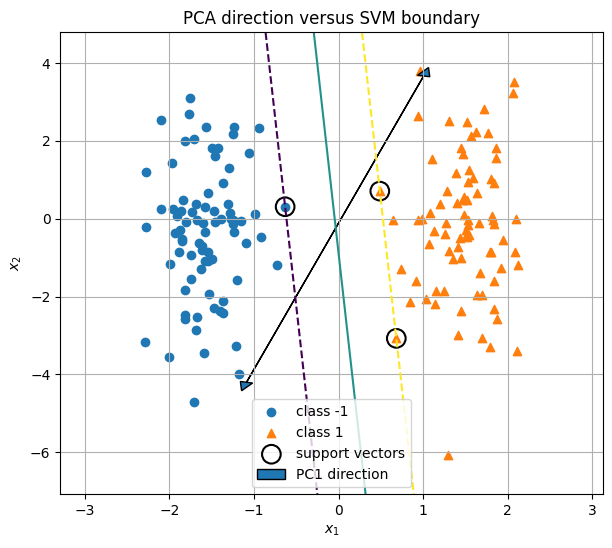

Linear SVM accuracy on original 2D data = 1.000
Linear SVM accuracy after projection to PC1 = 0.644
First principal component direction: [0.257  0.9664]


In [8]:
# Hint: create vertically elongated classes whose centers differ mostly in x.
rng_local = np.random.default_rng(7)

mean_neg = np.array([-1.5, 0.0])
mean_pos = np.array([ 1.5, 0.0])
Sigma = np.array([
    [0.15, 0.0],
    [0.0, 3.5]
])

X_neg = rng_local.multivariate_normal(mean_neg, Sigma, size=80)
X_pos = rng_local.multivariate_normal(mean_pos, Sigma, size=80)

X = np.vstack([X_neg, X_pos])
y = np.hstack([
    -np.ones(len(X_neg), dtype=int),
     np.ones(len(X_pos), dtype=int)
])

# Fit PCA and SVM
pca = PCA(n_components=1)
X_1d = pca.fit_transform(X)

clf_2d = SVC(kernel='linear', C=1e6)
clf_2d.fit(X, y)

clf_1d = SVC(kernel='linear', C=1e6)
clf_1d.fit(X_1d, y)

acc_2d = accuracy_score(y, clf_2d.predict(X))
acc_1d = accuracy_score(y, clf_1d.predict(X_1d))

# Plot data, first principal component, and SVM boundary
fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_function(clf_2d, X, y, ax=ax, title="PCA direction versus SVM boundary")

center = pca.mean_
pca_dir = pca.components_[0]
scale = max(X.std(axis=0)) * 2.5

ax.arrow(center[0], center[1],
         scale * pca_dir[0], scale * pca_dir[1],
         length_includes_head=True, head_width=0.15,
         label="PC1 direction")
ax.arrow(center[0], center[1],
         -scale * pca_dir[0], -scale * pca_dir[1],
         length_includes_head=True, head_width=0.15)

ax.legend()
plt.show()

print(f"Linear SVM accuracy on original 2D data = {acc_2d:.3f}")
print(f"Linear SVM accuracy after projection to PC1 = {acc_1d:.3f}")
print("First principal component direction:", np.round(pca_dir, 4))

The linear SVM gets perfect accuracy on the original 2D data, so the classes are linearly separable when both features are used.

After projecting the data to only the first principal component, the accuracy drops to 0.644. By reducing the data to PC1, we lose some information from the original 2D space that was important for classification.

## Exercise 7. Kernel trick on a nonlinear dataset


Use either the moons dataset or the circles dataset.

1. Fit a linear SVM.
2. Fit a polynomial-kernel SVM.
3. Fit an RBF-kernel SVM.
4. Plot the decision boundaries and explain which kernel works best and why.


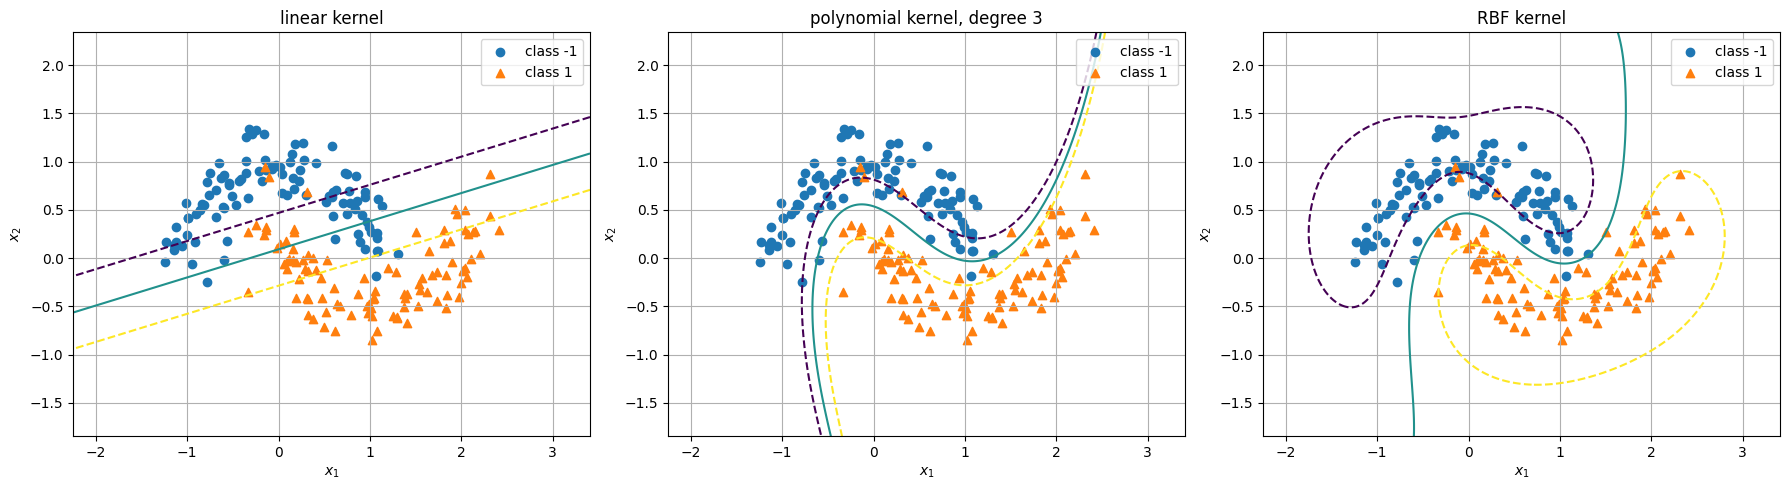

Model | training accuracy | support vectors
linear kernel                | 0.860 |  72
polynomial kernel, degree 3  | 0.970 |  40
RBF kernel                   | 0.975 |  48

Best training accuracy: RBF kernel


In [10]:
X, y = make_moons(n_samples=200, noise=0.18, random_state=2)
y = 2 * y - 1

# TODO: compare linear, polynomial, and RBF kernels

models = [
    ("linear kernel", SVC(kernel="linear", C=1.0)),
    ("polynomial kernel, degree 3", SVC(kernel="poly", degree=3, coef0=1.0, C=1.0)),
    ("RBF kernel", SVC(kernel="rbf", gamma="scale", C=1.0)),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results = []

for ax, (name, clf) in zip(axes, models):
    clf.fit(X, y)
    plot_decision_function(clf, X, y, ax=ax, title=name, show_support=False)

    preds = clf.predict(X)
    acc = accuracy_score(y, preds)
    n_support = len(clf.support_)
    results.append((name, acc, n_support))

plt.tight_layout()
plt.show()

print("Model | training accuracy | support vectors")
for name, acc, n_support in results:
    print(f"{name:28s} | {acc:.3f} | {n_support:3d}")

best_model = max(results, key=lambda t: t[1])
print(f"\nBest training accuracy: {best_model[0]}")

The linear kernel gives the lowest training accuracy. This suggests that the data is not perfectly separable by a straight line. The polynomial kernel and the RBF kernel perform much better, because they can create nonlinear decision boundaries.

The RBF kernel gives the highest training accuracy, so it is the best model in this comparison.

## Exercise 8. Short conceptual comparison


Answer the following in complete sentences.

1. Why is PCA unsupervised while SVM is supervised?
2. Why does the dual formulation naturally lead to kernels?
3. Why are support vectors the only training points that matter directly in the final decision function?



1. PCA is unsupervised because it only looks at the data and finds directions with the largest variance. SVM is supervised because it tries to find a decision boundary and learns how to separate the classes.

2. The dual formulation leads to kernels because a kernel can replace the dot product and allows SVM to create nonlinear decision boundaries.

3. Support vectors matter because they are the points closest to the decision boundary. They define the margin and directly influence the final classifier. Points that are far from the boundary usually do not change the result.

In [ ]:
# Write your answers in markdown above.
